# Spectral line fitting — Plantilla reutilizable

Detecta y caracteriza líneas espectrales en absorción o emisión sobre **cualquier** espectro óptico. Para cada línea ajusta el continuo local con dos pasos sigma-clipping y prueba tres modelos: **single Gaussian**, **blended (dos Gaussianas)** y **core emission** (absorción + emisión central). Elige el mejor por BIC y entrega EW.

Adaptado del pipeline LAMOST (`notebooks/4_LAMOST.ipynb`) pero generalizado: el lector del FITS y la lista de líneas son parámetros.

**Editar solo la celda `CONFIG`.**

## 0. EJEMPLO RÁPIDO (espectro LAMOST real)

Usa el espectro LAMOST `spec-56573-KP185031N425443V01_sp08-241.fits` (R ≈ 1300, SNR ≈ 142) y mide tres líneas clásicas: Hγ, He I 4471 y Mg II 4481.

Asegúrate de tener activado el ambiente `standards` (`conda activate standards`).


In [1]:
# --- Ejemplo: un espectro LAMOST real ---
from pathlib import Path

LAMOST_PATH = str(Path('example_data/spec-56573-KP185031N425443V01_sp08-241.fits'))

EXAMPLE_CONFIG_OVERRIDES = {
    'spectrum_path': LAMOST_PATH,
    'reader':        'lamost',
    'rv_kms':        0.0,
    'R':             1300,
    'norm_range':    [4000, 5000],
    'detection_threshold': 3.0,
    'lines': [
        {'name': 'Hgamma',    'lambda': 4340.5,
         'blue_cont': [4290, 4320], 'red_cont': [4360, 4390],
         'line_window': [4320, 4360]},
        {'name': 'HeI 4471',  'lambda': 4471.0,
         'blue_cont': [4445, 4465], 'red_cont': [4490, 4510],
         'line_window': [4465, 4490], 'companion': 4481.0},
        {'name': 'MgII 4481', 'lambda': 4481.0,
         'blue_cont': [4460, 4475], 'red_cont': [4495, 4515],
         'line_window': [4475, 4495], 'companion': 4471.0},
    ],
    'output_dir': 'example_line_fits_lamost',
}
print(f'Procesará {LAMOST_PATH}')


Procesará example_data/spec-56573-KP185031N425443V01_sp08-241.fits


## 1. CONFIG

In [2]:
from pathlib import Path

CONFIG = {
    # --- Espectro ---
    'spectrum_path':  'path/to/spectrum.fits',
    'reader':         'lamost',   # 'lamost' | 'generic_fits' | 'csv'
    'rv_kms':         0.0,        # corrección radial velocity (km/s) que se aplicará: λ' = λ (1 + v/c)
    'R':              1300,       # resolución espectral del espectro de entrada

    # --- Normalización inicial (continuo global) ---
    'norm_range':     [4000, 5000],   # [Å] rango donde se ajusta el continuo global
    'norm_poly_deg':  1,

    # --- Detección ---
    'detection_threshold': 3.0,   # σ sobre el continuo local

    # --- Líneas a medir ---
    # Cada línea: {'name', 'lambda', 'blue_cont', 'red_cont', 'line_window', 'companion'?}
    # - blue_cont/red_cont: regiones de continuo a cada lado, en Å
    # - line_window: [λ_min, λ_max] alrededor de la línea
    # - companion (opcional): λ de una línea blendeada cercana (habilita ajuste doble Gaussiano)
    'lines': [
        {'name': 'HeI 4471',  'lambda': 4471.0,
         'blue_cont': [4445, 4465], 'red_cont': [4490, 4510],
         'line_window': [4465, 4490], 'companion': 4481.0},
        {'name': 'MgII 4481', 'lambda': 4481.0,
         'blue_cont': [4460, 4475], 'red_cont': [4495, 4515],
         'line_window': [4475, 4495], 'companion': 4471.0},
    ],

    # --- Salida ---
    'output_dir': 'line_fit_results',
    'save_plots': True,
}

OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)

# Si la sección 0 (ejemplo) se ejecutó, aplica sus overrides automáticamente
try:
    CONFIG.update(EXAMPLE_CONFIG_OVERRIDES)
    print('CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES')
except NameError:
    pass
OUT = Path(CONFIG['output_dir'])
OUT.mkdir(parents=True, exist_ok=True)


CONFIG actualizado con EXAMPLE_CONFIG_OVERRIDES


## 2. Imports

In [3]:
import sys
from math import log
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.integrate
from scipy import stats
from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error
from astropy.io import fits
from astropy import constants as const

C_KMS = const.c.to('km/s').value

## 3. Lectores de espectro

Añade tu propio reader si trabajas con un instrumento distinto. La interfaz es: `reader(path) -> (wave_AA, flux, ivar)`. Si no tienes `ivar`, devuélvelo como `None` y se usará `ones_like(flux)`.

In [4]:
def _to_little_endian(arr):
    if arr.dtype.byteorder == '<' or (arr.dtype.byteorder == '=' and sys.byteorder == 'little'):
        return arr
    return arr.byteswap().view(arr.dtype.newbyteorder('<'))

def read_lamost(path):
    with fits.open(path) as hdul:
        flux, ivar, wave, andmask, ormask, norm = hdul[1].data[0]
    return _to_little_endian(np.asarray(wave)), _to_little_endian(np.asarray(flux)), _to_little_endian(np.asarray(ivar))

def read_generic_fits(path, wave_ext='WAVE', flux_ext='FLUX', ivar_ext=None):
    with fits.open(path) as hdul:
        wave = np.asarray(hdul[wave_ext].data)
        flux = np.asarray(hdul[flux_ext].data)
        ivar = np.asarray(hdul[ivar_ext].data) if ivar_ext else None
    return wave, flux, ivar

def read_csv_spec(path):
    df = pd.read_csv(path)
    wave = df['lambda'].values if 'lambda' in df.columns else df['wave'].values
    flux = df['flux'].values
    ivar = df['ivar'].values if 'ivar' in df.columns else None
    return wave, flux, ivar

READERS = {'lamost': read_lamost, 'generic_fits': read_generic_fits, 'csv': read_csv_spec}

## 4. Utilidades — normalización, integración, modelos

In [5]:
def interpolate_zeros(df):
    df = df.copy()
    df.loc[df['flux'] == 0, 'flux'] = np.nan
    df['flux'] = df['flux'].interpolate(method='linear')
    return df

def normalize_spectrum(wave, flux, ivar, poly_deg=1, wave_range=(4000, 5000), bins=50,
                       std_quantile_cut=0.7):
    """Normaliza por un polinomio robusto en `wave_range`.
    Bins en λ + corta los bins con mayor dispersión (líneas), ajusta poly y divide."""
    if ivar is None:
        ivar = np.ones_like(flux)
    if np.mean(wave) < 1000:  # heurística LAMOST: log10(λ)
        wave = 10 ** wave
    df = pd.DataFrame({'lambda': wave, 'flux': flux, 'ivar': ivar})
    df = interpolate_zeros(df)
    df = df.loc[(df['lambda'] >= wave_range[0]) & (df['lambda'] <= wave_range[1])]
    df['e_flux'] = np.sqrt(1.0 / df['ivar'])
    full = df.copy()
    df['bins'] = pd.cut(df['lambda'], bins=bins)
    df['flux_std'] = df.groupby('bins', observed=False)['flux'].transform('std')
    df = df.loc[df['flux_std'] < df['flux_std'].quantile(std_quantile_cut)].reset_index(drop=True)
    snr = (df['flux'] * np.sqrt(df['ivar'])).median()
    coeffs = np.polyfit(df['lambda'], df['flux'], poly_deg)
    full['flux_norm']  = full['flux']  / np.polyval(coeffs, full['lambda'])
    full['e_flux_norm'] = full['e_flux'] / np.polyval(coeffs, full['lambda'])
    return full.reset_index(drop=True), float(snr)

def idl_tabulated(x, f, p=5):
    """Integral por Newton–Cotes en segmentos de tamaño `p` (estilo IDL TABULATE)."""
    def seg(xs, fs):
        if xs.shape[0] < 2:
            return 0.0
        r = (xs.shape[0]-1) * (xs - xs[0]) / (xs[-1] - xs[0])
        w = scipy.integrate.newton_cotes(r)[0]
        return (xs[-1] - xs[0]) / (xs.shape[0]-1) * np.dot(w, fs)
    total = 0.0
    for i in range(0, x.shape[0], p-1):
        total += seg(x[i:i+p], f[i:i+p])
    return total

def gauss(x, A, x0, sigma, b):
    return A * np.exp(-(x - x0)**2 / (2 * sigma**2)) + b

def two_gauss(x, A1, x01, s1, A2, x02, s2, b):
    return gauss(x, A1, x01, s1, b/2) + gauss(x, A2, x02, s2, b/2)

def gauss_core_emission(x, A1, x01, s1, b1, A2, s2):
    return gauss(x, A1, x01, s1, b1) + gauss(x, A2, x01, s2, 0)

def bic(n, mse, k):
    return n * log(mse) + k * log(n)

## 5. Detección de línea + continuo local

In [6]:
def detect_line(spectra, blue_cont, red_cont, line_window, lambda_peak,
                threshold=3.0, ax=None):
    """Refina el continuo local con dos pasadas sigma-clipping y detecta si hay
    absorción/emisión por encima de `threshold` σ. Devuelve (spectra_renormalizada,
    coeffs_continuo_local, line_type ∈ {'abs','ems','U'})."""
    sp = spectra.loc[(spectra['lambda'] > blue_cont[0]) & (spectra['lambda'] < red_cont[1])].copy()
    cont = sp.loc[
        ((sp['lambda'] > blue_cont[0]) & (sp['lambda'] < blue_cont[1])) |
        ((sp['lambda'] > red_cont[0])  & (sp['lambda'] < red_cont[1]))
    ]
    out_line = sp.loc[
        ((sp['lambda'] > blue_cont[0])     & (sp['lambda'] < line_window[0])) |
        ((sp['lambda'] > line_window[1])   & (sp['lambda'] < red_cont[1]))
    ].copy()

    s1, b1, *_ = stats.linregress(cont['lambda'], cont['flux'])
    out_line['res1'] = out_line['flux'] - (s1 * out_line['lambda'] + b1)
    inside = out_line.loc[np.abs(out_line['res1']) < out_line['res1'].std()]

    s3, b3, *_ = stats.linregress(inside['lambda'], inside['flux'])
    disp = np.std(inside['flux'] - (s3 * inside['lambda'] + b3))

    sp['cont_local'] = s3 * sp['lambda'] + b3
    sp['flux_norm_line'] = sp['flux'] / sp['cont_local']

    line = sp.loc[(sp['lambda'] > line_window[0]) & (sp['lambda'] < line_window[1])].copy()
    line['dev'] = np.abs(line['flux'] - line['cont_local'])
    near = line.loc[(line['lambda'] > lambda_peak-3) & (line['lambda'] < lambda_peak+3)]
    q95 = near['dev'].quantile(0.95) if len(near) else np.inf
    peak = near.loc[near['dev'] > q95]

    if (peak['dev'] > threshold*disp).any():
        line_type = 'ems' if (peak['flux'] > peak['cont_local']).any() else 'abs'
    else:
        line_type = 'U'

    if ax is not None:
        upper = line['cont_local'] + threshold*disp
        lower = line['cont_local'] - threshold*disp
        ax.plot(sp['lambda'], sp['flux'], 'o-', c='grey', alpha=0.5)
        ax.plot(line['lambda'], line['flux'], 'o-', c='black')
        ax.scatter(cont['lambda'], cont['flux'], facecolors='none', edgecolors='r', s=30,
                   label='Continuum windows')
        ax.plot(out_line['lambda'], s1*out_line['lambda']+b1, ':', c='red', label='1st cont fit')
        ax.plot(out_line['lambda'], s3*out_line['lambda']+b3, '--', c='blue', label='Final local cont')
        ax.fill_between(line['lambda'], upper, lower, color='orange', alpha=0.4,
                        label=fr'$\pm${threshold}$\sigma$')
        ax.axvline(lambda_peak, c='purple', ls='--', label=fr'$\lambda${int(lambda_peak)}')
        ax.legend(fontsize=8)

    return sp.reset_index(drop=True), (s3, b3), line_type

## 6. Ajuste Gaussiano — single / blended / core-emission

Prueba los tres modelos y se queda con el de **mayor BIC** (criterio del notebook original). Calcula EW por integración Newton–Cotes sobre `[λ₀ − 4σ, λ₀ + 4σ]`.

In [7]:
def _amplitude_bounds(line_type):
    if line_type == 'abs':
        return -np.inf, 0
    return 0, np.inf

def fit_line_models(spectra, lambda_1, lambda_2, line_type, coeffs, R,
                    cota_mean=3.0, ax=None):
    """Devuelve dict con keys: model, EW, EW2, params, lambda_fit, sigma_fit."""
    x = spectra['lambda'].values
    y = spectra['flux_norm_line'].values
    sigma0 = lambda_1 / (R * 2.634)
    b0     = pd.Series(y).quantile(0.9)
    cont_mean = pd.Series(y).mean()

    near = spectra.loc[(spectra['lambda'] > lambda_1 - cota_mean) &
                       (spectra['lambda'] < lambda_1 + cota_mean), 'flux_norm_line']
    if line_type == 'abs':
        amp1 = -(1 - (near.min() - cont_mean))
    else:
        amp1 = near.max() - cont_mean
    A_lo, A_hi = _amplitude_bounds(line_type)

    p0_s   = [amp1, lambda_1, sigma0, b0]
    bnd_s  = ([A_lo, lambda_1-cota_mean, sigma0, 0], [A_hi, lambda_1+cota_mean, np.inf, 1.5])
    try:
        p_s, _ = curve_fit(gauss, x, y, p0=p0_s, bounds=bnd_s, max_nfev=10000)
    except (ValueError, RuntimeError):
        return {'model': 'U', 'EW': np.nan, 'EW2': np.nan, 'params': None,
                'lambda_fit': np.nan, 'sigma_fit': np.nan, 'bic': np.nan}

    line_mask = (spectra['lambda'] > p_s[1]-4*p_s[2]) & (spectra['lambda'] < p_s[1]+4*p_s[2])
    x_l, y_l = spectra.loc[line_mask, 'lambda'].values, spectra.loc[line_mask, 'flux'].values
    bic_s = bic(len(y_l), mean_squared_error(y_l, gauss(x_l, *p_s)), len(p_s))

    bic_d, p_d = -np.inf, None
    if lambda_2 is not None:
        l2 = lambda_2 + (p_s[1] - lambda_1)
        p0_d  = [amp1, lambda_1, sigma0, amp1, l2, sigma0, b0]
        bnd_d = ([-np.inf, lambda_1-cota_mean, sigma0, -np.inf, l2-cota_mean, sigma0, 0],
                 [0,      lambda_1+cota_mean, np.inf, 0,       l2+cota_mean, np.inf, 1.5])
        try:
            p_d, _ = curve_fit(two_gauss, x, y, p0=p0_d, bounds=bnd_d, max_nfev=10000)
            bic_d  = bic(len(y_l), mean_squared_error(y_l, two_gauss(x_l, *p_d)), len(p_d))
        except (ValueError, RuntimeError):
            pass

    bic_c, p_c = -np.inf, None
    p0_c  = [p_s[0], p_s[1], p_s[2], p_s[-1], -amp1/2, sigma0]
    bnd_c = ([-np.inf, lambda_1-cota_mean, sigma0,   0, 0,      sigma0/2],
             [0,       lambda_1+cota_mean, np.inf, 1.1, np.inf, sigma0])
    try:
        p_c, _ = curve_fit(gauss_core_emission, x, y, p0=p0_c, bounds=bnd_c, max_nfev=50000)
        bic_c  = bic(len(y_l), mean_squared_error(y_l, gauss_core_emission(x_l, *p_c)), len(p_c))
    except (ValueError, RuntimeError):
        pass

    bics  = [bic_s, bic_d, bic_c]
    names = ['Single', 'Blended', 'CoreEmission']
    params  = [p_s, p_d, p_c]
    lambdas = [p_s[1], p_d[1] if p_d is not None else np.nan, p_c[1] if p_c is not None else np.nan]
    sigmas  = [p_s[2], p_d[2] if p_d is not None else np.nan, p_c[2] if p_c is not None else np.nan]
    idx = int(np.argmax(bics))

    band = (spectra['lambda'] > lambdas[idx]-4*sigmas[idx]) & (spectra['lambda'] < lambdas[idx]+4*sigmas[idx])
    df_ew = spectra.loc[band].reset_index(drop=True)
    x_ew, y_ew = df_ew['lambda'].values, df_ew['flux'].values
    EW, EW2 = np.nan, np.nan
    if names[idx] in ('Single', 'CoreEmission'):
        cont_line = coeffs[0]*x_ew + coeffs[1]
        EW = idl_tabulated(x_ew, 1 - (y_ew/cont_line))
    else:  # Blended
        g1 = gauss(x_ew, *np.concatenate((p_d[:3], [p_d[-1]])))
        g2 = gauss(x_ew, *p_d[3:])
        EW  = idl_tabulated(x_ew, 1 - g1)
        EW2 = idl_tabulated(x_ew, 1 - g2)

    if ax is not None:
        ax.set_title(f'{line_type} | {names[idx]} | EW={EW:.2f} Å')
        if names[idx] == 'Blended':
            ax.plot(spectra['lambda'], spectra['flux_norm_line'], 'o-', c='grey')
            ax.plot(df_ew['lambda'], df_ew['flux_norm_line'], 'o-', c='black')
            ax.plot(x_ew, g1, '--', c='red',  label='Gauss 1')
            ax.plot(x_ew, g2, '--', c='blue', label='Gauss 2')
        else:
            ax.plot(spectra['lambda'], spectra['flux'], 'o-', c='grey')
            ax.plot(df_ew['lambda'], df_ew['flux'], 'o-', c='black')
            ax.plot(spectra['lambda'], coeffs[0]*spectra['lambda']+coeffs[1], c='green', label='Local cont')
        ax.axvline(lambdas[idx]-4*sigmas[idx], c='r', ls='--')
        ax.axvline(lambdas[idx]+4*sigmas[idx], c='r', ls='--')
        ax.legend(fontsize=8)

    return {'model': names[idx], 'EW': EW, 'EW2': EW2, 'params': params[idx],
            'lambda_fit': lambdas[idx], 'sigma_fit': sigmas[idx], 'bic': bics[idx]}

## 7. Pipeline — corre todas las líneas del CONFIG

Espectro cargado. SNR ≈ 143.1, λ ∈ [4000.4, 4999.2] Å


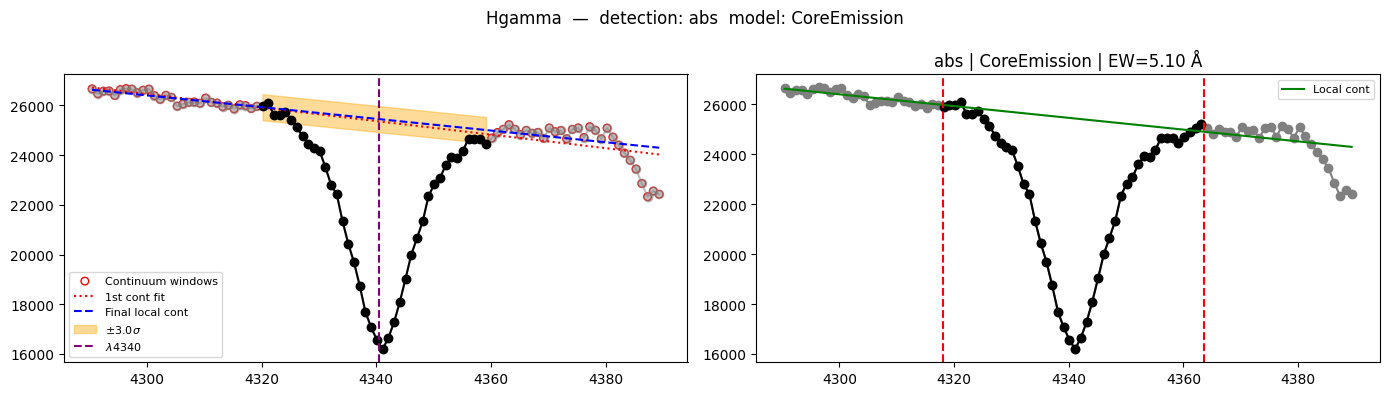

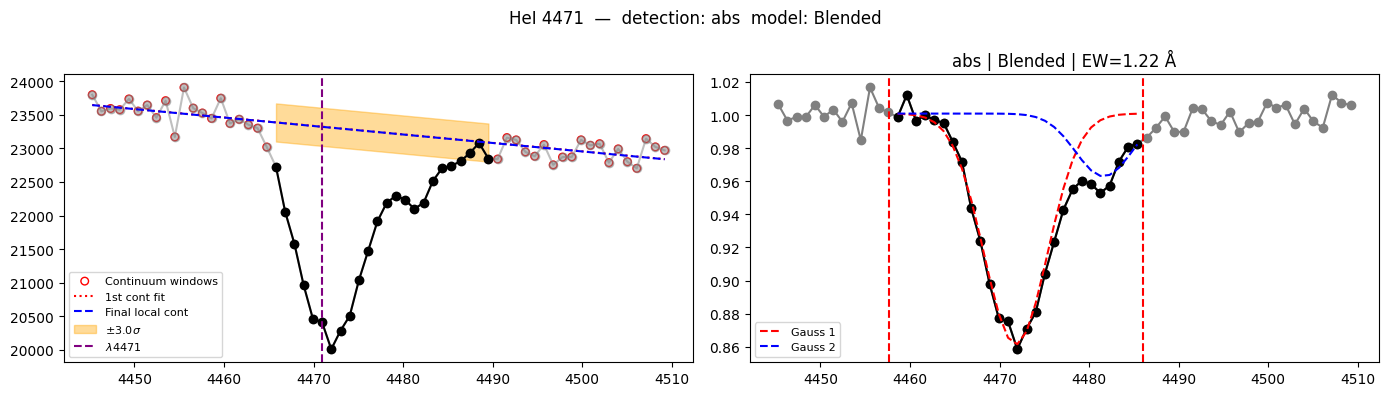

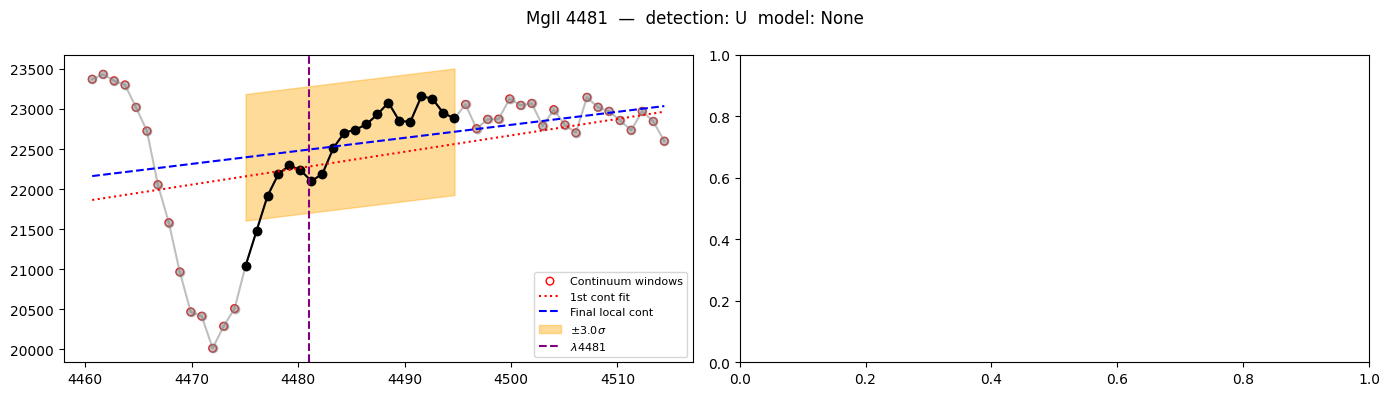

     line detection        model       EW      EW2
   Hgamma       abs CoreEmission 5.100600      NaN
 HeI 4471       abs      Blended 1.216253 0.241152
MgII 4481         U            U      NaN      NaN


In [8]:
reader = READERS[CONFIG['reader']]
wave, flux, ivar = reader(CONFIG['spectrum_path'])
spectra, snr = normalize_spectrum(wave, flux, ivar,
                                  poly_deg=CONFIG['norm_poly_deg'],
                                  wave_range=tuple(CONFIG['norm_range']))
spectra['lambda'] = spectra['lambda'] + (CONFIG['rv_kms'] / C_KMS) * spectra['lambda']
print(f'Espectro cargado. SNR ≈ {snr:.1f}, λ ∈ [{spectra["lambda"].min():.1f}, {spectra["lambda"].max():.1f}] Å')

rows = []
for line in CONFIG['lines']:
    name = line['name']
    try:
        if CONFIG['save_plots']:
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        else:
            axes = [None, None]
        sp, coeffs, ltype = detect_line(
            spectra, line['blue_cont'], line['red_cont'], line['line_window'],
            line['lambda'], CONFIG['detection_threshold'], ax=axes[0],
        )
        if ltype == 'U':
            rows.append({'line': name, 'detection': ltype, 'model': 'U',
                         'EW': np.nan, 'EW2': np.nan, 'lambda_fit': np.nan, 'sigma_fit': np.nan})
            res_model = None
        else:
            res = fit_line_models(
                sp, line['lambda'], line.get('companion'), ltype, coeffs,
                R=CONFIG['R'], ax=axes[1],
            )
            rows.append({'line': name, 'detection': ltype, **res})
            res_model = res['model']
        if CONFIG['save_plots']:
            fig.suptitle(f'{name}  —  detection: {ltype}  model: {res_model}')
            plt.tight_layout()
            plt.savefig(OUT / f'line_{name.replace(" ", "_")}.pdf', bbox_inches='tight')
            plt.show()
    except Exception as e:
        print(f'[!] {name}: {type(e).__name__}: {e}')
        rows.append({'line': name, 'detection': 'error', 'model': 'error',
                     'EW': np.nan, 'EW2': np.nan})

results = pd.DataFrame(rows)
results['snr'] = snr
results.to_csv(OUT / 'line_measurements.csv', index=False)
print(results[['line', 'detection', 'model', 'EW', 'EW2']].to_string(index=False))

## 8. Procesar muchos espectros (opcional)

Si tienes una tabla con varios espectros, envuelve el bloque 7 en una función y aplica con `pandarallel`:

```python
from pandarallel import pandarallel
pandarallel.initialize(progress_bar=True)

def process_one(path):
    cfg = dict(CONFIG, spectrum_path=path)
    # ... reusa el bloque 7 ...
    return results_dict

df['result'] = df['fits'].parallel_apply(process_one)
```